# **Trabajo Grupo 10 – Aprendizaje Supervisado**

### **Integrantes**
* Tomás Contreras
* Carlos Duarte
* Renato Atencio

### **Avisos**
Tras conversar con el profesor Matthieu, se decidió **utilizar el dataset correspondiente al Grupo 1**, debido a que los datos del dataset originalmente asignado al Grupo 10 presentaban inconsistencias que podían afectar el análisis.

**Transparencia:** Durante el desarrollo de este trabajo se utilizaron herramientas complementarias como ChatGPT y Claude, con los siguientes fines:
- Como inspiración para mejorar la redacción de algunas frases u oraciones que se vean extrañas, y corregir errores ortográficos.
- Apoyar en código para la creación de gráficos representativos para el análisis de los datos.

### **Objetivo**
El objetivo de este trabajo es aplicar técnicas de aprendizaje supervisado utilizando como variables predictoras las primeras cuatro columnas del dataset (`pm25`, `no2`, `trafico`, `viento`). En particular, se busca:

1. **Problema de clasificación:**
   Determinar si existe o no una condición de alerta.
2. **Problema de regresión:**
   Predecir los valores de contaminación.
3. **Evaluación crítica:**
   Analizar y evaluar la metodología empleada, así como la calidad de los resultados obtenidos, identificando posibles mejoras y limitaciones del enfoque utilizado.

### **Imports y Carga de datos** 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import numpy as np
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

In [2]:
ruta = Path("data/Grupo1.csv")
if not ruta.exists():
    ruta = Path("P3/Grupo1.csv")

df_raw = pd.read_csv(ruta, sep=";")

col_analisis = ["pm25", "no2", "trafico", "viento"]
col_clasificacion = "alerta"
col_regresion = "contaminacion"

### **Limpieza**

pm25       5
no2        5
trafico    5
viento     5
dtype: int64
pm25       0
no2        0
trafico    0
viento     0
dtype: int64


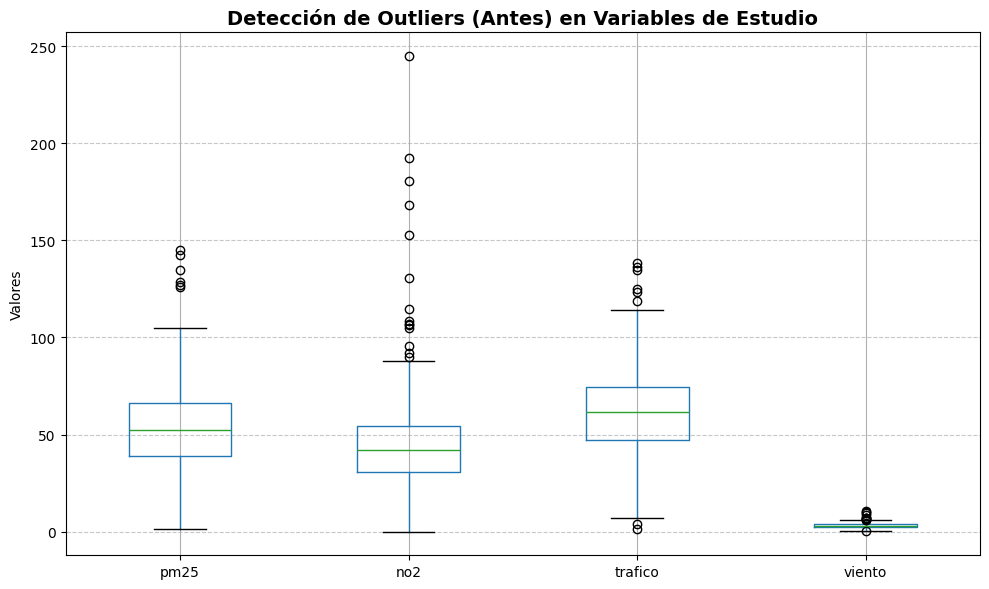

             pm25         no2     trafico      viento  contaminacion
count  458.000000  458.000000  458.000000  458.000000     458.000000
mean    53.810131   44.344127   61.785699    3.261397     141.645000
std     22.465846   24.349825   22.751395    1.277314      40.236008
min      1.310000    0.060000    1.440000    0.320000      38.980000
25%     39.057500   30.570000   47.147500    2.530000     116.982500
50%     52.125000   42.015000   61.380000    3.105000     138.980000
75%     66.355000   54.150000   74.652500    3.930000     164.215000
max    144.910000  244.840000  138.100000   10.530000     293.850000


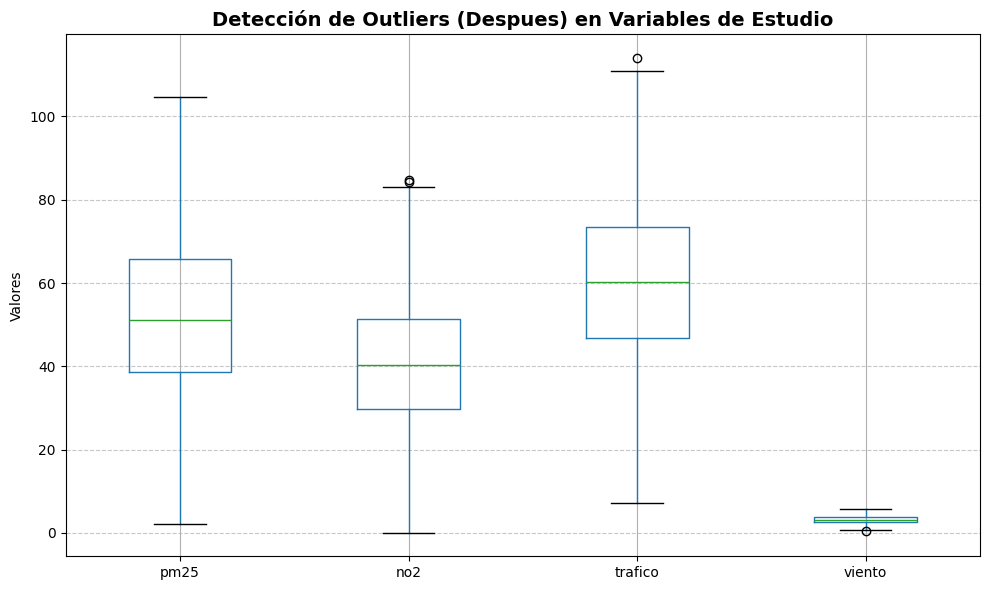

             pm25         no2     trafico      viento  contaminacion
count  429.000000  429.000000  429.000000  429.000000      429.00000
mean    52.446340   40.967319   60.244033    3.141772      138.10711
std     20.189647   16.502287   20.709577    1.012826       35.76671
min      2.180000    0.060000    7.230000    0.520000       38.98000
25%     38.710000   29.640000   46.890000    2.520000      115.93000
50%     51.160000   40.310000   60.330000    3.090000      137.94000
75%     65.670000   51.430000   73.350000    3.840000      160.87000
max    104.720000   84.770000  114.030000    5.780000      261.51000


In [3]:
# Check para ver si hay valores nulos
print(df_raw[col_analisis].isnull().sum())

# Nulos
df_clean = df_raw.dropna()

# Negativos
df_clean = df_clean.loc[
    (df_clean["no2"] > 0) &
    (df_clean["pm25"] > 0) &
    (df_clean["trafico"] > 0) &
    (df_clean["viento"] > 0) &
    (df_clean["contaminacion"] > 0)
]

# Check para ver si hay valores nulos
print(df_clean[col_analisis].isnull().sum())

# Outliers
# Vista de outliers
plt.figure(figsize=(10, 6))
df_clean[col_analisis].boxplot()
plt.title("Detección de Outliers (Antes) en Variables de Estudio", fontsize=14, fontweight="bold")
plt.ylabel("Valores")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("eda_outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_clean.describe())

## Metodo de limpieza basado en IQR
for col in col_analisis:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= limite_inferior) & (df_clean[col] <= limite_superior)]

# Grafico sin los outliers
plt.figure(figsize=(10, 6))
df_clean[col_analisis].boxplot()
plt.title("Detección de Outliers (Despues) en Variables de Estudio", fontsize=14, fontweight="bold")
plt.ylabel("Valores")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("eda_outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_clean.describe())

## **Problema de clasificacion**

In [4]:
# Convertimos la variable de clasificacion a 0/1.
df_clean[col_clasificacion] = df_clean[col_clasificacion].map({
    True: 1,
    False: 0,
    "True": 1,
    "False": 0,
})

print("\nCantidad de ejemplos por clase:")
print(df_clean[col_clasificacion].value_counts(dropna=False))
# Este print nos indica que existe un desvalanceo en el dataframe, 
# no es critico pero se debe tener en cuenta


Cantidad de ejemplos por clase:
alerta
0    297
1    132
Name: count, dtype: int64


### **Resolución con regresión logistica**

In [5]:
def evaluar_clasificacion(nombre_modelo, y_real, y_pred):
    print(f"=== {nombre_modelo} ===")
    print(f"Accuracy: {accuracy_score(y_real, y_pred):.3f}")
    print("\nReporte de clasificacion:")
    print(classification_report(
        y_real,
        y_pred,
        target_names=["No alerta", "Alerta"],
        zero_division=0,
    ))

    matriz = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No alerta", "Alerta"],
        yticklabels=["No alerta", "Alerta"],
    )
    plt.title(f"Matriz de confusion - {nombre_modelo}")
    plt.xlabel("Prediccion")
    plt.ylabel("Valor real")
    plt.show()

In [6]:
X = df_clean[col_analisis]
y = df_clean[col_clasificacion].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (343, 4)
Test size: (86, 4)


=== Regresion Logistica ===
Accuracy: 0.849

Reporte de clasificacion:
              precision    recall  f1-score   support

   No alerta       0.85      0.95      0.90        60
      Alerta       0.84      0.62      0.71        26

    accuracy                           0.85        86
   macro avg       0.85      0.78      0.80        86
weighted avg       0.85      0.85      0.84        86



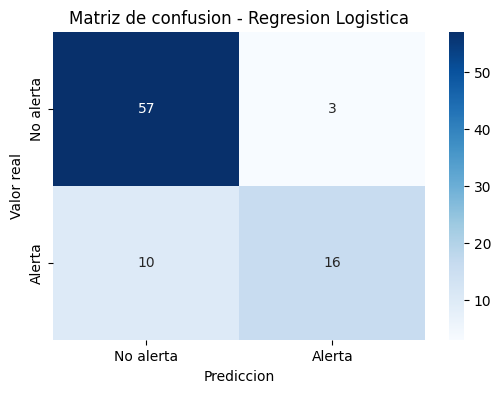

In [7]:
# Regresion Logistica (Especifico para binario)
modelo_logistico = LogisticRegression(max_iter=100)
modelo_logistico.fit(X_train, y_train)

y_pred_logistico = modelo_logistico.predict(X_test)
evaluar_clasificacion("Regresion Logistica", y_test, y_pred_logistico)

### **Resolución con arbol de decision**

=== Arbol de Decision ===
Accuracy: 0.826

Reporte de clasificacion:
              precision    recall  f1-score   support

   No alerta       0.83      0.95      0.88        60
      Alerta       0.82      0.54      0.65        26

    accuracy                           0.83        86
   macro avg       0.82      0.74      0.77        86
weighted avg       0.83      0.83      0.81        86



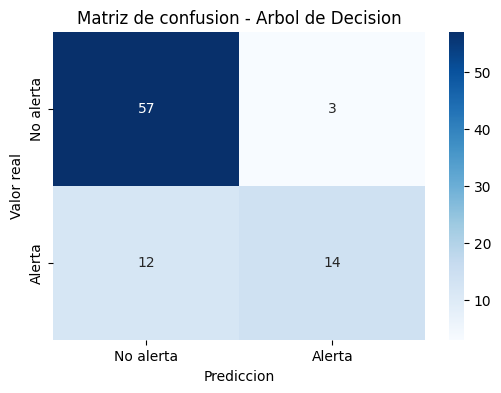

In [8]:
# Arbol de Decision
modelo_arbol_clasificacion = DecisionTreeClassifier(criterion="gini", max_depth=3, splitter="best")
modelo_arbol_clasificacion.fit(X_train, y_train)

y_pred_arbol_clasificacion = modelo_arbol_clasificacion.predict(X_test)
evaluar_clasificacion("Arbol de Decision", y_test, y_pred_arbol_clasificacion)

## **Problema de regresión**
Con RandomForest y utilizando GridSearch para encontrar los mejores parametros

In [45]:
def evaluar_regresion(nombre_modelo, y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R2: {r2:.3f}")

In [10]:
X_reg = df_clean[col_analisis]
y_reg = df_clean[col_regresion]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
)

print("Train:", X_train_reg.shape)
print("Test:", X_test_reg.shape)

Train: (343, 4)
Test: (86, 4)


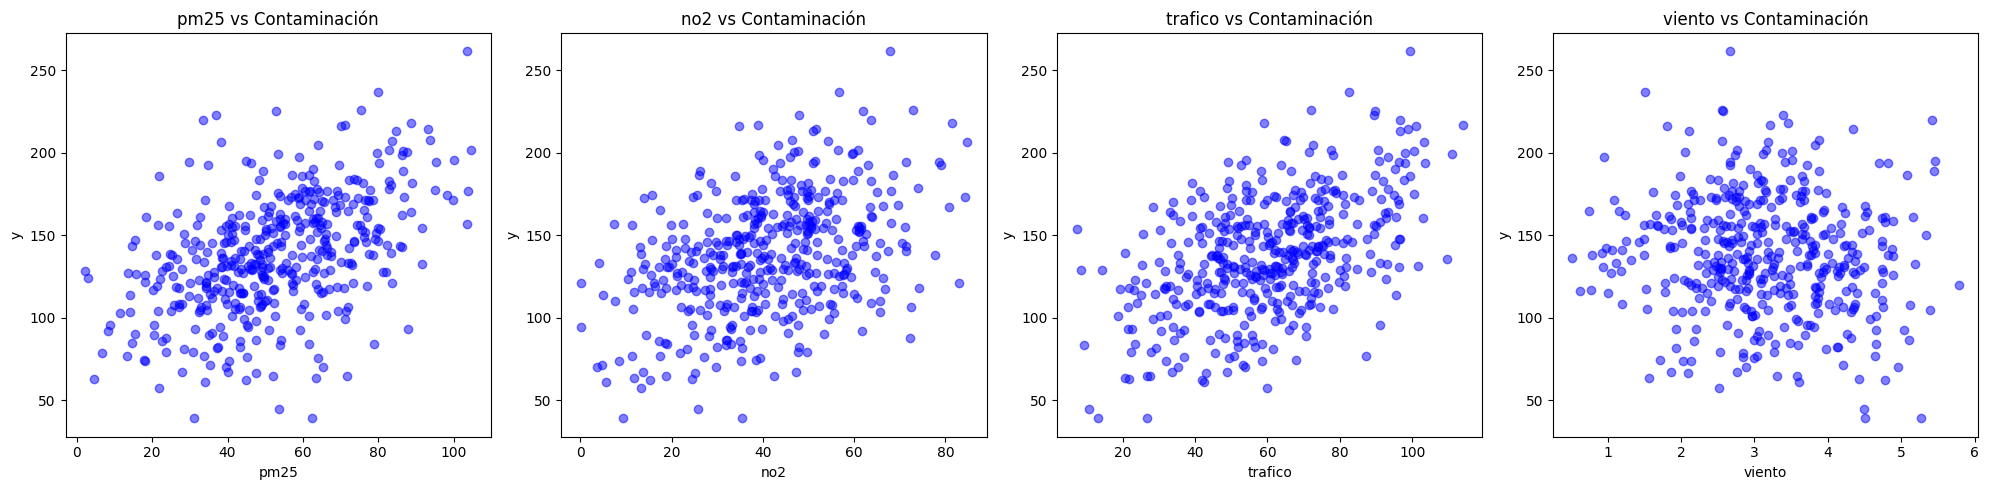

In [11]:
# Graficar relación de cada variable con el objetivo
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(col_analisis):
    axes[i].scatter(X_reg[col], y_reg, color='blue', alpha=0.5)
    axes[i].set_title(f"{col} vs Contaminación")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()


In [37]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4], 
    'max_features': ['sqrt', 'log2', None] 
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_reg, y_train_reg)

print("Mejores parámetros:", grid_search.best_params_)
modelo_optimizado = grid_search.best_estimator_

Mejores parámetros: {'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [38]:
y_pred_rf = modelo_optimizado.predict(X_test_reg)

In [ ]:
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)

evaluar_regresion("Random Forest", y_test_reg.values, y_pred_rf)

MSE: 601.400
RMSE: 24.523
MAE: 19.314
R2: 0.594


In [47]:
resultados_regresion = pd.DataFrame({
    "real": y_test_reg.values, 
    "pred_rf": y_pred_rf
})

resultados_regresion.head(10)

,real,pred_rf
0,159.66,138.347796
1,153.37,142.202052
2,74.36,126.455140
3,143.46,132.445244
4,160.32,158.249448
5,213.32,200.284846
6,64.58,130.631355
7,133.19,132.319715
8,150.07,131.954461
9,79.39,100.078789


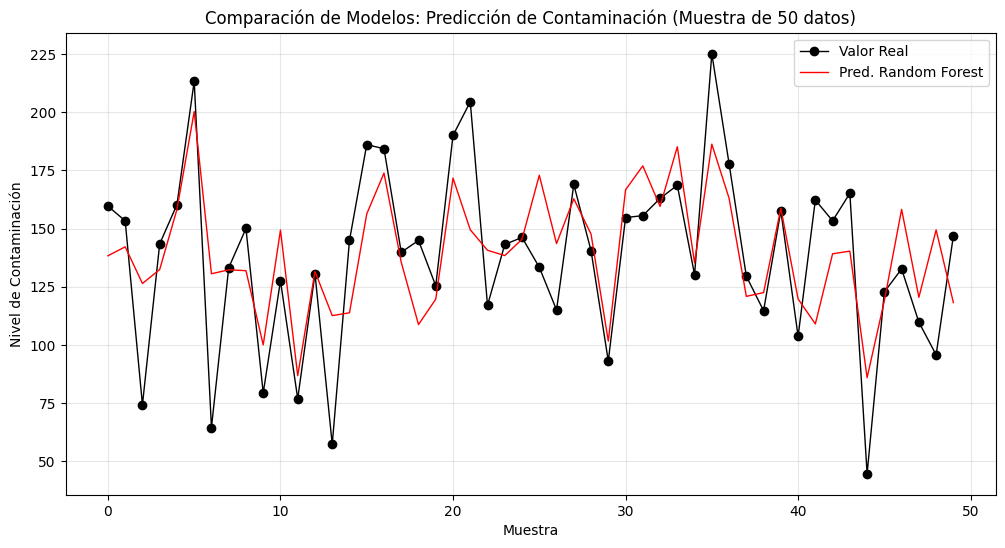

In [48]:
plt.figure(figsize=(12, 6))

df_sample = resultados_regresion.head(50)

plt.plot(df_sample['real'].values, label='Valor Real', color='black', linewidth=1, marker='o')
plt.plot(df_sample['pred_rf'].values, label='Pred. Random Forest', color='red', linewidth=1)

plt.title("Comparación de Modelos: Predicción de Contaminación (Muestra de 50 datos)")
plt.xlabel("Muestra")
plt.ylabel("Nivel de Contaminación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

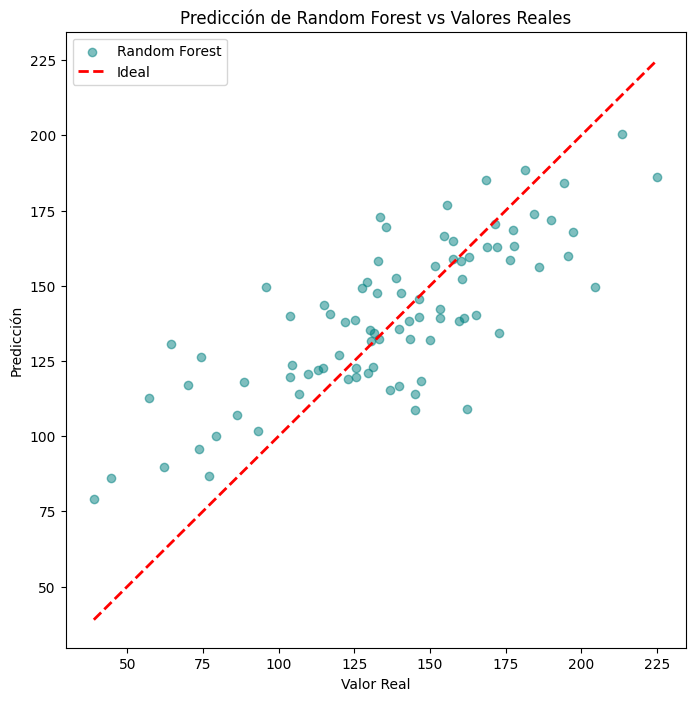

In [49]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_reg, y_pred_rf, alpha=0.5, color='teal', label='Random Forest')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Ideal')

plt.title("Predicción de Random Forest vs Valores Reales")
plt.xlabel("Valor Real")
plt.ylabel("Predicción")
plt.legend()
plt.show()

## Analisis y conclusión

En este trabajo se aplicaron técnicas de aprendizaje supervisado para poder enfrentarnos a dos problemas distintos usando las variables `pm25`, `no2`, `trafico` y `viento`, por un lado, la clasificación de la variable `alerta`, y por otro, la predicción del nivel de `contaminacion`.

Primero se realizó una limpieza de datos, eliminando valores nulos, registros con valores no válidos y observaciones atípicas. Esto permitió trabajar con un conjunto más consistente, aunque también es importante que mencionemos algo que puede ocurrir con datos ambientales y es que algunos valores más extremos podrían representar eventos que ocurrieron de verdad y que corresponden a una alta contaminación. Entonces esta decisión en general mejora la estabilidad del modelo, pero también podría reducir la presencia de casos críticos.

Para el problema de clasificación se entrenaron dos modelos: regresión logística y árbol de decisión. Aquí cabe mencionar que la variable `alerta` presentaba cierto desbalance, ya que tenía más casos de “No alerta” que de “Alerta”, por lo que no basta con solo mirar el accuracy. La regresión logística obtuvo un accuracy de 0.849 y tuvo un mejor desempeño general que el árbol de decisión, especialmente en la clase “Alerta”, donde alcanzó un recall de 0.62. Consiguió detectar 16 de los 26 casos reales de alerta en el conjunto de prueba, aunque todavía dejó 10 alertas sin detectar. En cambio el árbol de decisión tuvo un accuracy de 0.826 y con un recall más bajo para la clase “Alerta” de 0.54, por lo que fue menos efectivo identificando situaciones críticas.

En este contexto, la regresión logística parece ser la mejor alternativa entre los dos modelos probados. Aunque ambos modelos clasifican bien los casos sin alerta, una de las cosas más importante del problema (desde nuestro punto de vista) es no dejar pasar demasiadas alertas reales.

Para el problema de regresión se utilizó un Random Forest Regressor optimizado mediante GridSearchCV. El modelo obtuvo un R2 de 0.594, un MAE de 19.314 y un RMSE de 24.523. Estos resultados indican que el modelo logra capturar una parte relevante de la variabilidad de la contaminación, pero no explica completamente el fenómeno.

Los gráficos de dispersión muestran que `pm25`, `no2` y `trafico` tienen una relación positiva más clara con la contaminación, mientras que `viento` presenta una relación más débil y dispersa. Además, en el gráfico de valores reales versus predichos se observa que el modelo sigue la tendencia general, pero tiende a suavizar los extremos: sobreestima algunos valores bajos y subestima algunos valores altos. Esto es común en modelos de regresión cuando los casos extremos son más difíciles de aprender.

En conclusión, la metodología aplicada es adecuada para el objetivo del trabajo, ya que se resolvieron correctamente ambos problemas (problema de clasificación y de regresión usando aprendizaje supervisado). Los resultados son razonables y muestran que las variables disponibles sí contienen información útil para predecir alerta y contaminación. Sin embargo, el desempeño no es perfecto, especialmente en la detección de alertas reales y en la predicción de valores extremos de contaminación. Como mejora, sería recomendable usar validación cruzada de forma más amplia, fijar semillas para asegurar reproducibilidad, comparar más modelos de regresión y evaluar estrategias específicas para manejar el desbalance de clases.